In [1]:
# Phase1: Data Cleaning
import pandas as pd
import numpy as np
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
print(df.head())

   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80          75      

In [2]:
print(df.shape)

(374, 13)


In [3]:
print(df.columns)

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')


In [4]:
print(df.dtypes)

Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object


In [5]:
print(df.isnull().sum())

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


In [6]:
df["Sleep Disorder"].value_counts(dropna=False)

Sleep Disorder
NaN            219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [7]:
print(df["Sleep Disorder"].unique())

[nan 'Sleep Apnea' 'Insomnia']


In [8]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

In [9]:
print(df.isnull().sum())

Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64


In [10]:
print(df["Sleep Disorder"].value_counts())

Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


In [11]:
missing_percent = (df.isnull().sum() / len(df)) * 100

print(missing_percent)

Person ID                  0.0
Gender                     0.0
Age                        0.0
Occupation                 0.0
Sleep Duration             0.0
Quality of Sleep           0.0
Physical Activity Level    0.0
Stress Level               0.0
BMI Category               0.0
Blood Pressure             0.0
Heart Rate                 0.0
Daily Steps                0.0
Sleep Disorder             0.0
dtype: float64


In [12]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [13]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (374, 13)


In [14]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


Gender
['Male' 'Female']

Occupation
['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager']

BMI Category
['Overweight' 'Normal' 'Obese' 'Normal Weight']

Blood Pressure
['126/83' '125/80' '140/90' '120/80' '132/87' '130/86' '117/76' '118/76'
 '128/85' '131/86' '128/84' '115/75' '135/88' '129/84' '130/85' '115/78'
 '119/77' '121/79' '125/82' '135/90' '122/80' '142/92' '140/95' '139/91'
 '118/75']

Sleep Disorder
['None' 'Sleep Apnea' 'Insomnia']


In [15]:
print(df["BMI Category"].value_counts())

BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64


In [16]:
df["BMI Category"] = df["BMI Category"].replace({
    "Normal Weight": "Normal"
})

In [17]:
print(df["BMI Category"].value_counts())

BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64


In [18]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [20]:
numerical_cols = [
    'Age',
    'Sleep Duration',
    'Quality of Sleep',
    'Physical Activity Level',
    'Stress Level',
    'Heart Rate',
    'Daily Steps'
]

In [21]:
for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
Sleep Duration: 0 outliers
Quality of Sleep: 0 outliers
Physical Activity Level: 0 outliers
Stress Level: 0 outliers
Heart Rate: 15 outliers
Daily Steps: 0 outliers


In [24]:
print(df["Quality of Sleep"].min())
print(df["Quality of Sleep"].max())

4
9


In [25]:
print(df["Stress Level"].min())
print(df["Stress Level"].max())

3
8


In [26]:
print(df["Sleep Duration"].min())
print(df["Sleep Duration"].max())

5.8
8.5


In [27]:
print(df["Sleep Disorder"].value_counts())

Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


In [28]:
print(df["Gender"].value_counts())

Gender
Male      189
Female    185
Name: count, dtype: int64


In [29]:
print(df["Occupation"].value_counts())

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64


In [30]:
df.to_csv(
    "cleaned_sleep_lifestyle_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [33]:
# Phase1: Data Cleaning Completed

In [34]:
#Phase 2: EDA
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

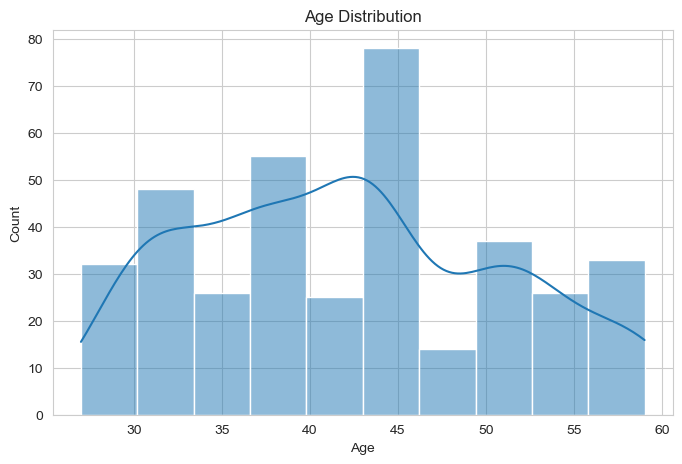

Most participants belong to middle-age working population
Age range approximately 27–59 years.


In [54]:
#Age Distribution 
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=10, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()
print("Most participants belong to middle-age working population")
print("Age range approximately 27–59 years.")

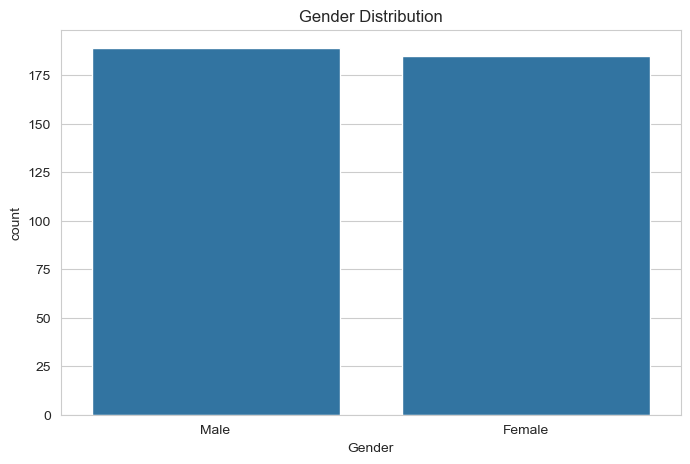

Male and Female distribution is nearly balanced.


In [55]:
# Gender Distribution
sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")
plt.show()
print("Male and Female distribution is nearly balanced.")

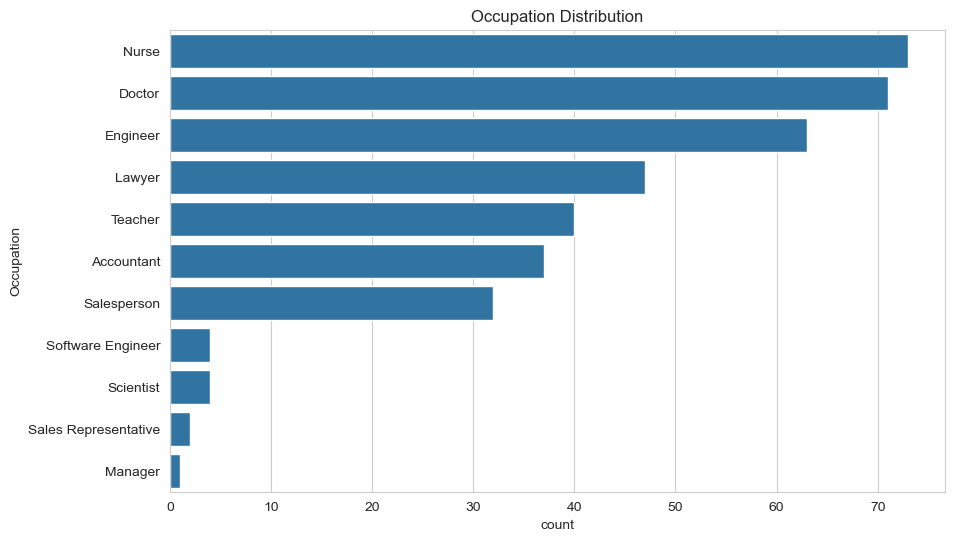

Nurses and Doctors dominate the dataset.
Few occupations have very small representation.


In [56]:
# Occupation Distribution
plt.figure(figsize=(10,6))

sns.countplot(
    y="Occupation",
    data=df,
    order=df["Occupation"].value_counts().index
)

plt.title("Occupation Distribution")
plt.show()
print("Nurses and Doctors dominate the dataset.")
print("Few occupations have very small representation.")

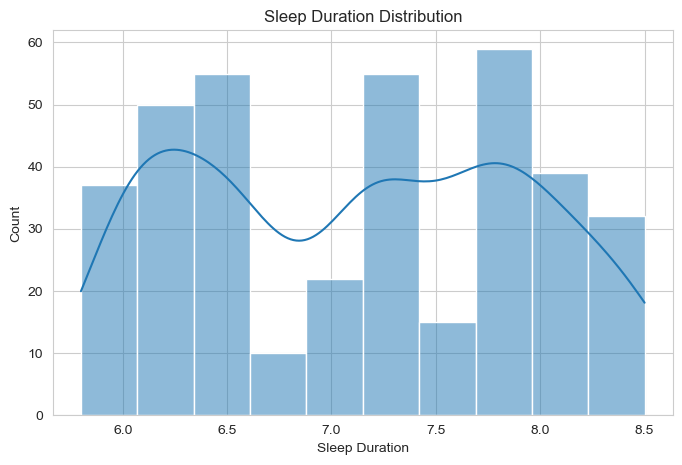

Most individuals sleep between 6–8 hours.


In [60]:
# Sleep Duration Distribution
sns.histplot(df["Sleep Duration"], bins=10, kde=True)

plt.title("Sleep Duration Distribution")
plt.show()
print("Most individuals sleep between 6–8 hours.")

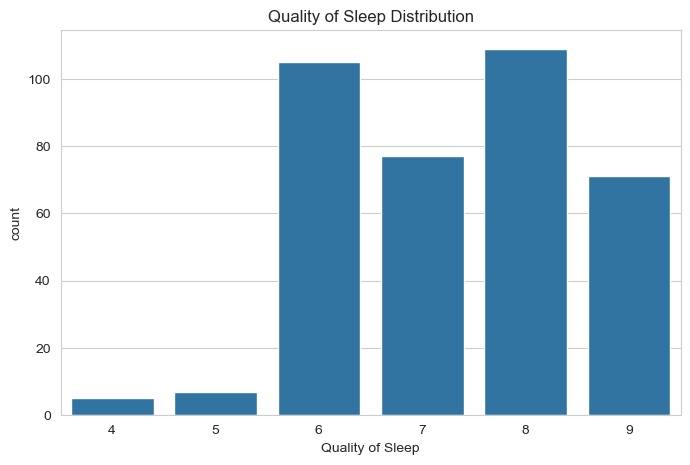

Most people report sleep quality between 6–8.


In [61]:
# Quality of Sleep Distribution
sns.countplot(x="Quality of Sleep", data=df)

plt.title("Quality of Sleep Distribution")
plt.show()
print("Most people report sleep quality between 6–8.")

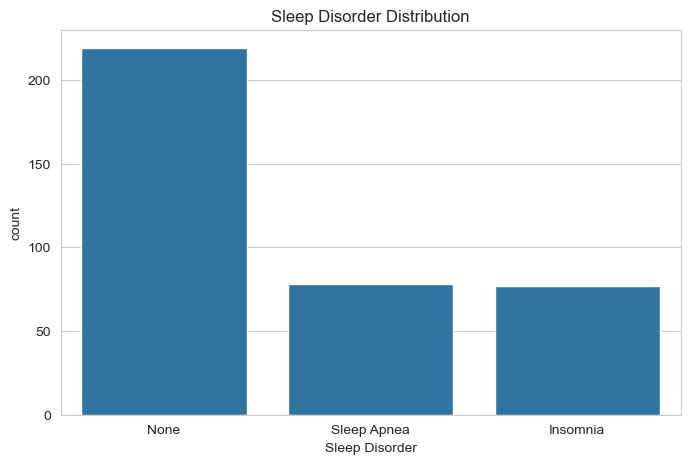

Majority have no sleep disorder.
Sleep Apnea and Insomnia are nearly equally represented.


In [62]:
# Sleep Disorder Distribution
sns.countplot(x="Sleep Disorder", data=df)

plt.title("Sleep Disorder Distribution")
plt.show()
print("Majority have no sleep disorder.")
print("Sleep Apnea and Insomnia are nearly equally represented.")

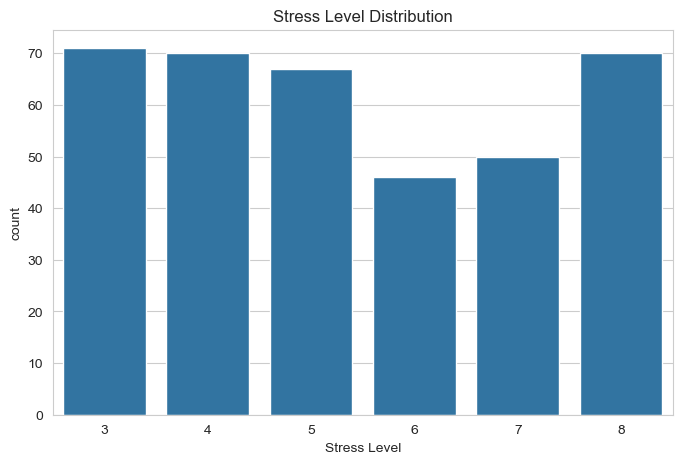

Most individuals exhibit moderate stress levels.


In [63]:
# Stress Level Distribution
sns.countplot(x="Stress Level", data=df)

plt.title("Stress Level Distribution")
plt.show()
print("Most individuals exhibit moderate stress levels.")

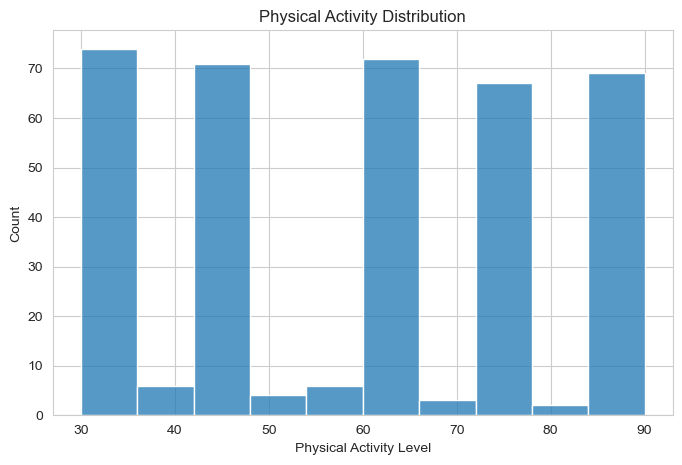

Physical activity varies significantly among participants.


In [64]:
# Physical Activity Distribution
sns.histplot(df["Physical Activity Level"], bins=10)

plt.title("Physical Activity Distribution")
plt.show()
print("Physical activity varies significantly among participants.")

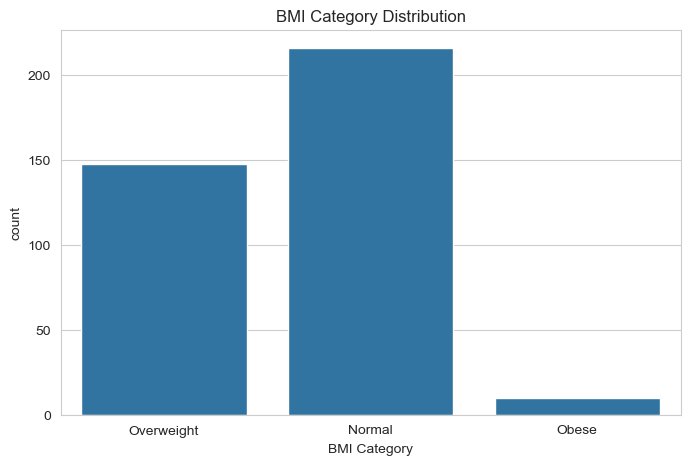

Majority belong to Normal or Overweight categories.


In [65]:
# BMI Category Distribution
sns.countplot(x="BMI Category", data=df)

plt.title("BMI Category Distribution")
plt.show()
print("Majority belong to Normal or Overweight categories.")

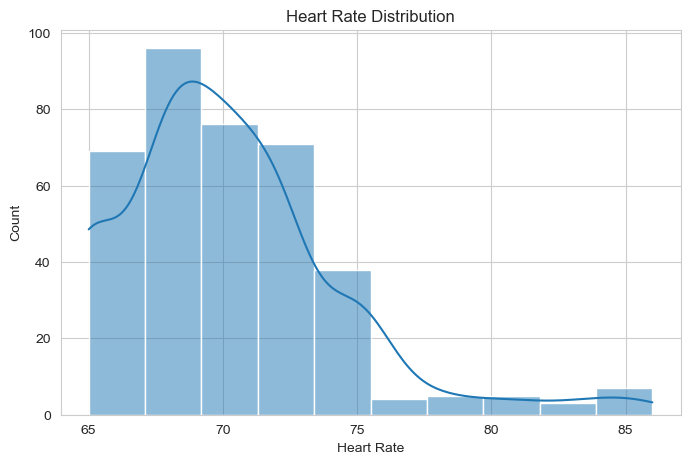

Heart Rate follows a near-normal distribution.
Few higher heart-rate observations exist.


In [66]:
# Heart Rate Distribution
sns.histplot(df["Heart Rate"], bins=10, kde=True)

plt.title("Heart Rate Distribution")
plt.show()
print("Heart Rate follows a near-normal distribution.")
print("Few higher heart-rate observations exist.")

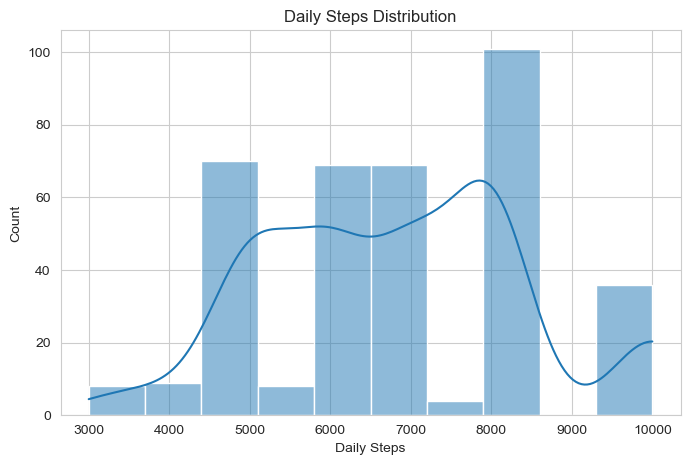

Most participants walk between 5000–9000 steps daily.


In [67]:
# Daily Steps Distribution
sns.histplot(df["Daily Steps"], bins=10, kde=True)

plt.title("Daily Steps Distribution")
plt.show()
print("Most participants walk between 5000–9000 steps daily.")

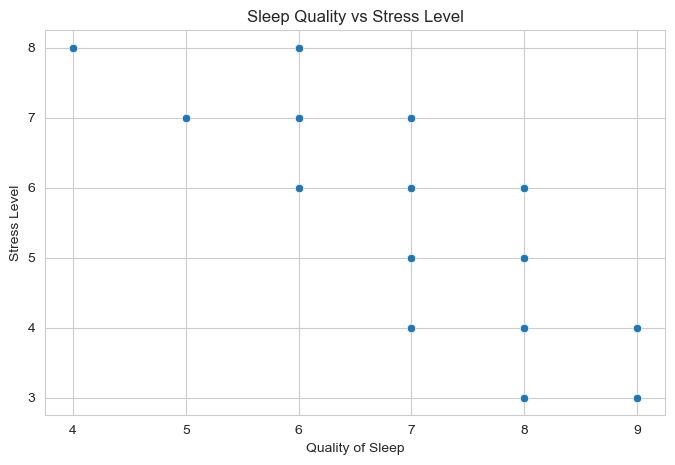

Sleep Quality ↑
Stress ↓


In [68]:
# Sleep Quality vs Stress
sns.scatterplot(
    x="Quality of Sleep",
    y="Stress Level",
    data=df
)

plt.title("Sleep Quality vs Stress Level")
plt.show()
print("Sleep Quality ↑")
print("Stress ↓")

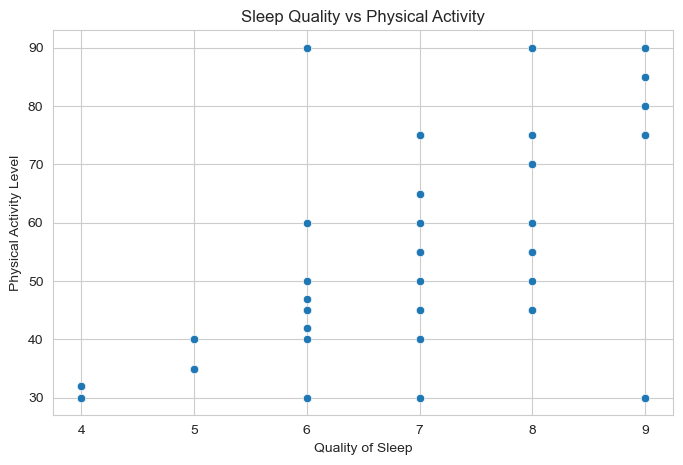

Sleep Quality ↑
Physical Activity ↑


In [69]:
# Sleep Quality vs Physical Activity
sns.scatterplot(
    x="Quality of Sleep",
    y="Physical Activity Level",
    data=df
)

plt.title("Sleep Quality vs Physical Activity")
plt.show()
print("Sleep Quality ↑")
print("Physical Activity ↑")

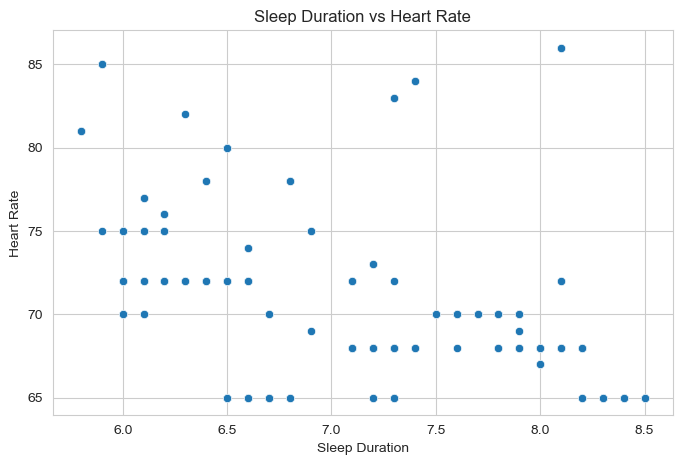

Sleep Duration ↑
Heart Rate ↓


In [70]:
# Sleep Duration vs Heart Rate
sns.scatterplot(
    x="Sleep Duration",
    y="Heart Rate",
    data=df
)

plt.title("Sleep Duration vs Heart Rate")
plt.show()
print("Sleep Duration ↑")
print("Heart Rate ↓")

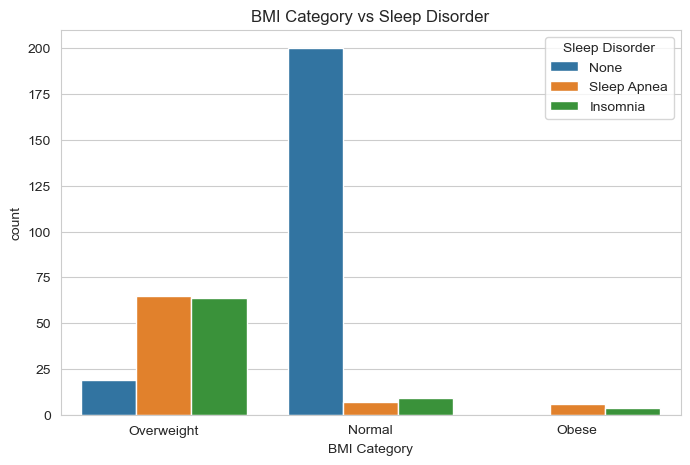

In [72]:
# BMI Category vs Sleep Disorder
sns.countplot(
    x="BMI Category",
    hue="Sleep Disorder",
    data=df
)

plt.title("BMI Category vs Sleep Disorder")
plt.show()

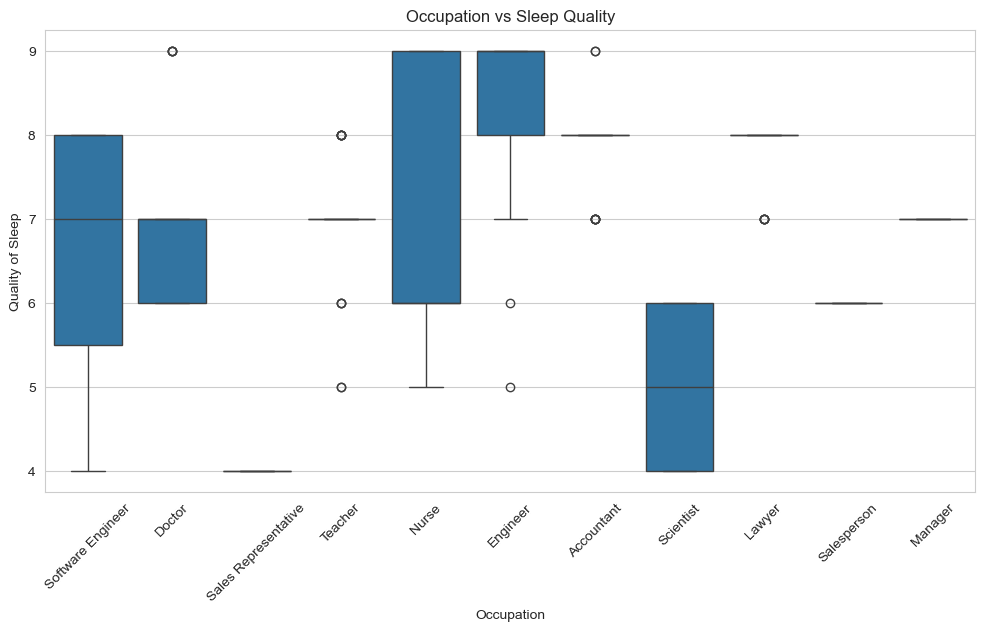

Different professions exhibit different sleep quality patterns.


In [73]:
# Occupation vs Sleep Quality
plt.figure(figsize=(12,6))

sns.boxplot(
    x="Occupation",
    y="Quality of Sleep",
    data=df
)

plt.xticks(rotation=45)

plt.title("Occupation vs Sleep Quality")
plt.show()
print("Different professions exhibit different sleep quality patterns.")

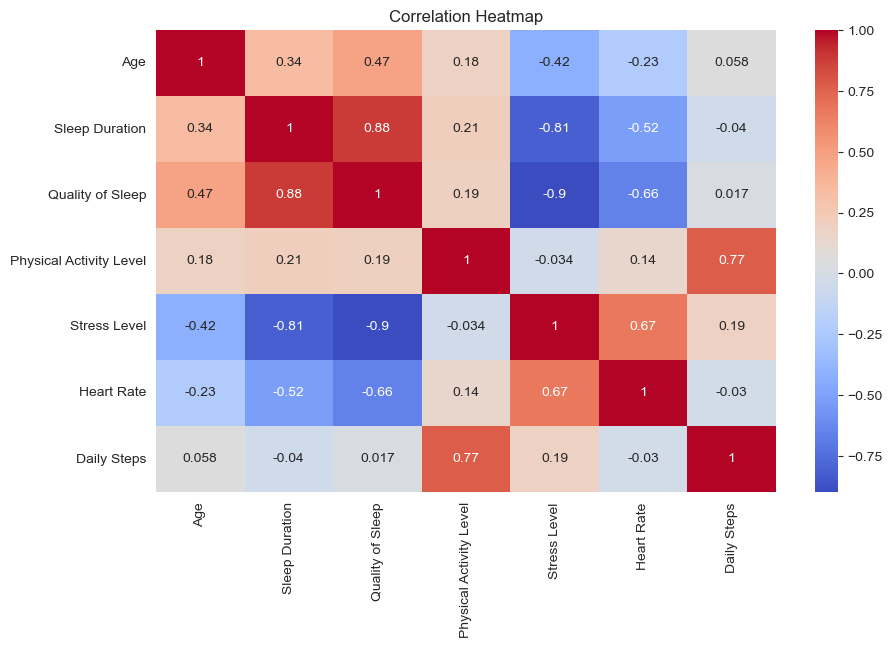

In [52]:
# Correlation Analysis
# Correlation Heatmap
numerical_cols = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps"
]

corr = df[numerical_cols].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [74]:
# Phase 3: STATISTICAL ANALYSIS
# SciPy was used to perform statistical hypothesis testing. 
# While EDA helped identify potential relationships, SciPy allowed us to validate whether those relationships were statistically significant using Pearson Correlation, ANOVA, and Chi-Square tests.

In [75]:
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
import pandas as pd
import numpy as np

In [79]:
# Sleep Quality vs Stress Level
# Hypothesis
# H0 : No relationship exists
# H1 : Relationship exists


# Interpretation
# Correlation > 0  → Positive Relation

# Correlation < 0  → Negative Relation

# p-value < 0.05   → Significant


corr, p_value = pearsonr(
    df["Quality of Sleep"],
    df["Stress Level"]
)

print("Correlation:", round(corr,3))
print("P-value:", p_value)
print("\nA very strong negative correlation (r = -0.899) was observed between Sleep Quality and Stress Level. The relationship was statistically significant (p < 0.05), indicating that individuals with better sleep quality tend to experience lower stress levels.")

Correlation: -0.899
P-value: 2.88012424094341e-135

A very strong negative correlation (r = -0.899) was observed between Sleep Quality and Stress Level. The relationship was statistically significant (p < 0.05), indicating that individuals with better sleep quality tend to experience lower stress levels.


In [80]:
# Sleep Quality vs Physical Activity
corr, p_value = pearsonr(
    df["Quality of Sleep"],
    df["Physical Activity Level"]
)

print("Correlation:", round(corr,3))
print("P-value:", p_value)

Correlation: 0.193
P-value: 0.0001745489524783864


In [81]:
# Sleep Duration vs Heart Rate
corr, p_value = pearsonr(
    df["Sleep Duration"],
    df["Heart Rate"]
)

print("Correlation:", round(corr,3))
print("P-value:", p_value)

Correlation: -0.516
P-value: 6.914740131848265e-27


In [83]:
# Sleep Duration vs Stress
corr, p_value = pearsonr(
    df["Sleep Duration"],
    df["Stress Level"]
)

print("Correlation:", round(corr,3))
print("P-value:", p_value)

Correlation: -0.811
P-value: 1.2378076181537574e-88


In [84]:
# Correlation Summary Table
correlations = []

pairs = [
    ("Quality of Sleep","Stress Level"),
    ("Quality of Sleep","Physical Activity Level"),
    ("Sleep Duration","Heart Rate"),
    ("Sleep Duration","Stress Level")
]

for x,y in pairs:

    corr,p = pearsonr(df[x],df[y])

    correlations.append(
        [x,y,round(corr,3),round(p,5)]
    )

corr_df = pd.DataFrame(
    correlations,
    columns=[
        "Variable 1",
        "Variable 2",
        "Correlation",
        "P-value"
    ]
)

corr_df

,Variable 1,Variable 2,Correlation,P-value
0,Quality of Sleep,Stress Level,-0.899,0.00000
1,Quality of Sleep,Physical Activity Level,0.193,0.00017
2,Sleep Duration,Heart Rate,-0.516,0.00000
3,Sleep Duration,Stress Level,-0.811,0.00000


In [85]:
# ANOVA Test 

In [86]:
# BMI vs Sleep Quality
# Question: Does BMI Category affect Sleep Quality?

normal = df[df["BMI Category"]=="Normal"]["Quality of Sleep"]

overweight = df[df["BMI Category"]=="Overweight"]["Quality of Sleep"]

obese = df[df["BMI Category"]=="Obese"]["Quality of Sleep"]

f_stat,p_value = f_oneway(
    normal,
    overweight,
    obese
)

print("F-statistic:",f_stat)
print("P-value:",p_value)

#Body weight status is not only a physical health indicator but also has a statistically significant impact on sleep quality.

F-statistic: 22.011391400512753
P-value: 9.257968894758679e-10


In [87]:
df.groupby("BMI Category")["Quality of Sleep"].mean().sort_values(ascending=False)

BMI Category
Normal        7.638889
Overweight    6.898649
Obese         6.400000
Name: Quality of Sleep, dtype: float64

In [88]:
# BMI vs Stress Level
normal = df[df["BMI Category"]=="Normal"]["Stress Level"]

overweight = df[df["BMI Category"]=="Overweight"]["Stress Level"]

obese = df[df["BMI Category"]=="Obese"]["Stress Level"]

f_stat,p_value = f_oneway(
    normal,
    overweight,
    obese
)

print("F-statistic:",f_stat)
print("P-value:",p_value)

F-statistic: 5.222156402684291
P-value: 0.0057993991621457875
